In [307]:
import numpy as np
import matplotlib.pyplot as plt

# Dekompozycja SVD - Singular Value Decomposition

Imputacja - macierz niepełna

Jak bardo rozciąga: Alternatywna definicja uwarunokwania macierzy dla $||A||| ||A^{-1}||$.

$
\frac{\sigma_1}{\sigma_r}
$

In [308]:
grid_shape = (100, 100)

In [ ]:
def plot_sphere(A = np.identity(3), show = True, vis_svd: bool = False, alpha=0.2, color = 'b', ax = None):
    s = np.linspace(0, 2 * np.pi, 100)
    t = np.linspace(0, np.pi, 100)

    x = np.outer(np.cos(s), np.sin(t))
    y = np.outer(np.sin(s), np.sin(t))
    z = np.outer(np.ones(np.size(s)), np.cos(t))

    points = A @ np.vstack((x.flatten(), y.flatten(), z.flatten()))
    x, y, z = points[0].reshape(grid_shape), points[1].reshape(grid_shape), points[2].reshape(grid_shape)

    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(projection="3d")

    if vis_svd:
        u, s, _ = np.linalg.svd(A)

        eigenx = u[:, 0] * s[0]
        eigeny = u[:, 1] * s[1]
        eigenz = u[:, 2] * s[2]

        ax.quiver(0, 0, 0, eigenx[0], eigenx[1], eigenx[2], color='r')
        ax.quiver(0, 0, 0, *eigeny, color='g')
        ax.quiver(0, 0, 0, *eigenz, color='b')

    ax.plot_wireframe(x, y, z, color=color, alpha=alpha)

    if show:
        ax.set_aspect('equal')
        plt.show()

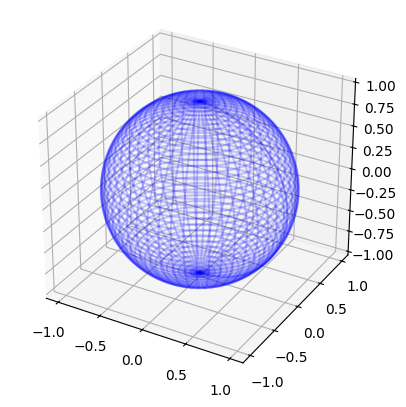

In [310]:
plot_sphere()

In [311]:
A1 = np.array([
    [2, 0.8, 0.3],
    [0, 1, 0.4],
    [-0.3, 0, 3],
])

A2 = np.array([
    [1, 0, 0.6],
    [0, 1, 0],
    [0.2, 0, 2],
])

A3 = np.array([
    [1, 0, 0],
    [0.2, 2, -0.5],
    [0, 0, 1],
])

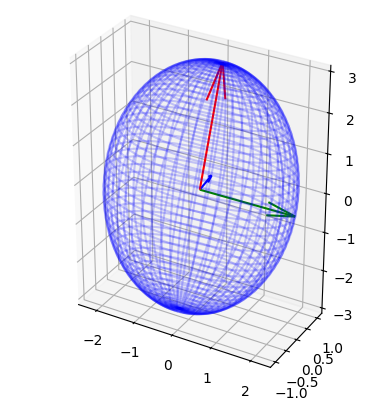

In [312]:
plot_sphere(A1, vis_svd=True)

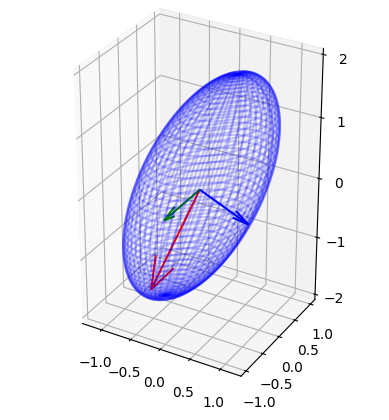

In [313]:
plot_sphere(A2, vis_svd=True)

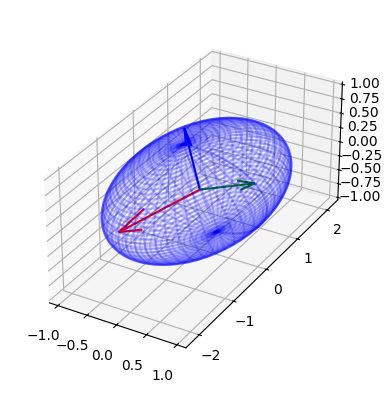

In [314]:
plot_sphere(A3, vis_svd=True)

In [315]:
A4 = np.array([
    [101, 0, 0],
    [0, 101, 0],
    [0, 0, 1],
])

u, s, _ = np.linalg.svd(A4)
display(s[0] / s[-1])

np.float64(101.0)

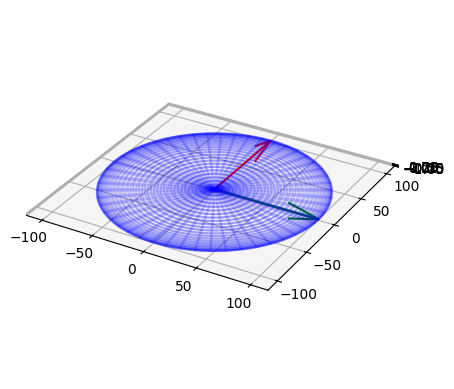

In [316]:
plot_sphere(A4, vis_svd=True)

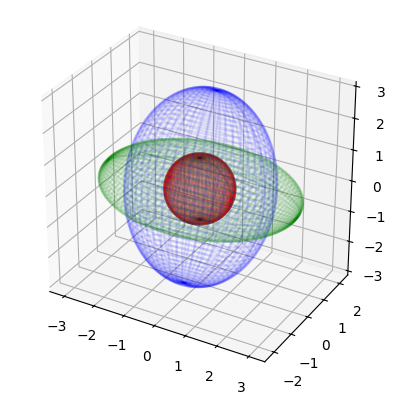

In [317]:
u, s, vh = np.linalg.svd(A1)

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

plot_sphere(A=u @ (s[..., None] * vh), show=False, color='b', ax=ax, alpha=0.1)
plot_sphere(A=s[..., None] * vh, show=False, color='g', ax=ax, alpha=0.1)
plot_sphere(A=vh, show=False, color='r', ax=ax, alpha=0.1)
plot_sphere(show=False, color='black', ax=ax, alpha=0.1)

ax.set_aspect('equal')
plt.show()